In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, models
from torchvision.models import VGG16_Weights
from torch.utils.data import DataLoader, Dataset, Subset
import pandas as pd
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

DATA_DIR    = 'gtsrb'
TEST_CSV    = os.path.join(DATA_DIR, 'Test.csv')
CKPT_PATH   = 'best_vgg16_gtsrb.pth'
NUM_CLASSES = 43
BATCH_SIZE  = 32

EPS_VALUES  = [0.01, 0.02, 0.05, 0.1]
PGD_STEPS   = 10
EVAL_SUBSET = 2000     # set to None to eval on full test set (slower)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')
print(f'PGD steps: {PGD_STEPS} | Eval subset: {EVAL_SUBSET or "full"}')

Using device: cuda
PGD steps: 10 | Eval subset: 2000


In [2]:
class GTSRBTestDataset(Dataset):
    def __init__(self, csv_path, root_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row['Path'])
        image = Image.open(img_path).convert('RGB')
        label = int(row['ClassId'])
        if self.transform:
            image = self.transform(image)
        return image, label


test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

full_test_dataset = GTSRBTestDataset(TEST_CSV, DATA_DIR, transform=test_transform)

if EVAL_SUBSET:
    torch.manual_seed(42)
    indices = torch.randperm(len(full_test_dataset))[:EVAL_SUBSET].tolist()
    eval_dataset = Subset(full_test_dataset, indices)
else:
    eval_dataset = full_test_dataset

test_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Load VGG16 model
model = models.vgg16(weights=None)
model.classifier[6] = nn.Linear(4096, NUM_CLASSES)
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model = model.to(device)
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

criterion = nn.CrossEntropyLoss()

# Baseline clean accuracy
correct, total = 0, 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        correct += (model(imgs).argmax(1) == labels).sum().item()
        total += labels.size(0)
clean_acc = correct / total
print(f'Clean accuracy: {clean_acc:.4f} ({clean_acc*100:.2f}%)')
print(f'Eval samples:   {total}')

Clean accuracy: 0.9310 (93.10%)
Eval samples:   2000


In [3]:
def fgsm_attack(model, images, labels, eps):
    """Fast Gradient Sign Method — single gradient step."""
    x = images.clone().requires_grad_(True)
    loss = criterion(model(x), labels)
    loss.backward()
    return (x + eps * x.grad.sign()).detach()

print('FGSM defined.')

FGSM defined.


In [4]:
def pgd_attack(model, images, labels, eps, alpha, steps):
    """PGD (Madry et al.) — iterated FGSM with random start and eps-ball projection."""
    x = images + torch.empty_like(images).uniform_(-eps, eps)
    x = torch.clamp(x, images - eps, images + eps).detach()
    for _ in range(steps):
        x = x.requires_grad_(True)
        loss = criterion(model(x), labels)
        loss.backward()
        x = (x + alpha * x.grad.sign()).detach()
        x = torch.clamp(x, images - eps, images + eps)
    return x

print('PGD defined.')

PGD defined.


In [5]:
def evaluate_attack(attack_fn):
    """
    Returns (adv_acc, asr) where:
      adv_acc = accuracy on adversarial examples (all samples)
      asr     = attack success rate = fraction of originally-correct images that get fooled
    """
    adv_correct = 0
    originally_correct = 0
    fooled = 0
    total = 0

    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        with torch.no_grad():
            clean_preds = model(imgs).argmax(1)
        clean_mask = (clean_preds == labels)

        adv = attack_fn(imgs, labels)

        with torch.no_grad():
            adv_preds = model(adv).argmax(1)

        adv_correct        += (adv_preds == labels).sum().item()
        originally_correct += clean_mask.sum().item()
        fooled             += (clean_mask & (adv_preds != labels)).sum().item()
        total              += labels.size(0)

    adv_acc = adv_correct / total
    asr     = fooled / originally_correct if originally_correct > 0 else 0.0
    return adv_acc, asr

print('evaluate_attack() defined.')

evaluate_attack() defined.


In [6]:
fgsm_results = {}

print(f'{"eps":>6} | {"Adv Acc":>9} | {"ASR":>9} | {"Drop":>9}')
print('-' * 45)
for eps in EPS_VALUES:
    adv_acc, asr = evaluate_attack(lambda imgs, labels, e=eps: fgsm_attack(model, imgs, labels, e))
    fgsm_results[eps] = {'acc': adv_acc, 'asr': asr}
    drop = (clean_acc - adv_acc) * 100
    print(f'{eps:>6.2f} | {adv_acc*100:>8.2f}% | {asr*100:>8.2f}% | {drop:>8.2f}pp')

print(f'\nClean baseline: {clean_acc*100:.2f}%')

   eps |   Adv Acc |       ASR |      Drop
---------------------------------------------
  0.01 |    17.20% |    81.53% |    75.90pp
  0.02 |    18.75% |    79.86% |    74.35pp
  0.05 |    28.75% |    69.23% |    64.35pp
  0.10 |    36.30% |    61.28% |    56.80pp

Clean baseline: 93.10%


In [7]:
pgd_results = {}

print(f'{"eps":>6} | {"Adv Acc":>9} | {"ASR":>9} | {"Drop":>9}  [steps={PGD_STEPS}]')
print('-' * 55)
for eps in EPS_VALUES:
    alpha = eps / 10
    adv_acc, asr = evaluate_attack(lambda imgs, labels, e=eps, a=alpha: pgd_attack(model, imgs, labels, e, a, PGD_STEPS))
    pgd_results[eps] = {'acc': adv_acc, 'asr': asr}
    drop = (clean_acc - adv_acc) * 100
    print(f'{eps:>6.2f} | {adv_acc*100:>8.2f}% | {asr*100:>8.2f}% | {drop:>8.2f}pp')

print(f'\nClean baseline: {clean_acc*100:.2f}%')

   eps |   Adv Acc |       ASR |      Drop  [steps=10]
-------------------------------------------------------
  0.01 |     2.05% |    97.80% |    91.05pp
  0.02 |     0.00% |   100.00% |    93.10pp
  0.05 |     0.20% |    99.79% |    92.90pp
  0.10 |     0.20% |    99.79% |    92.90pp

Clean baseline: 93.10%


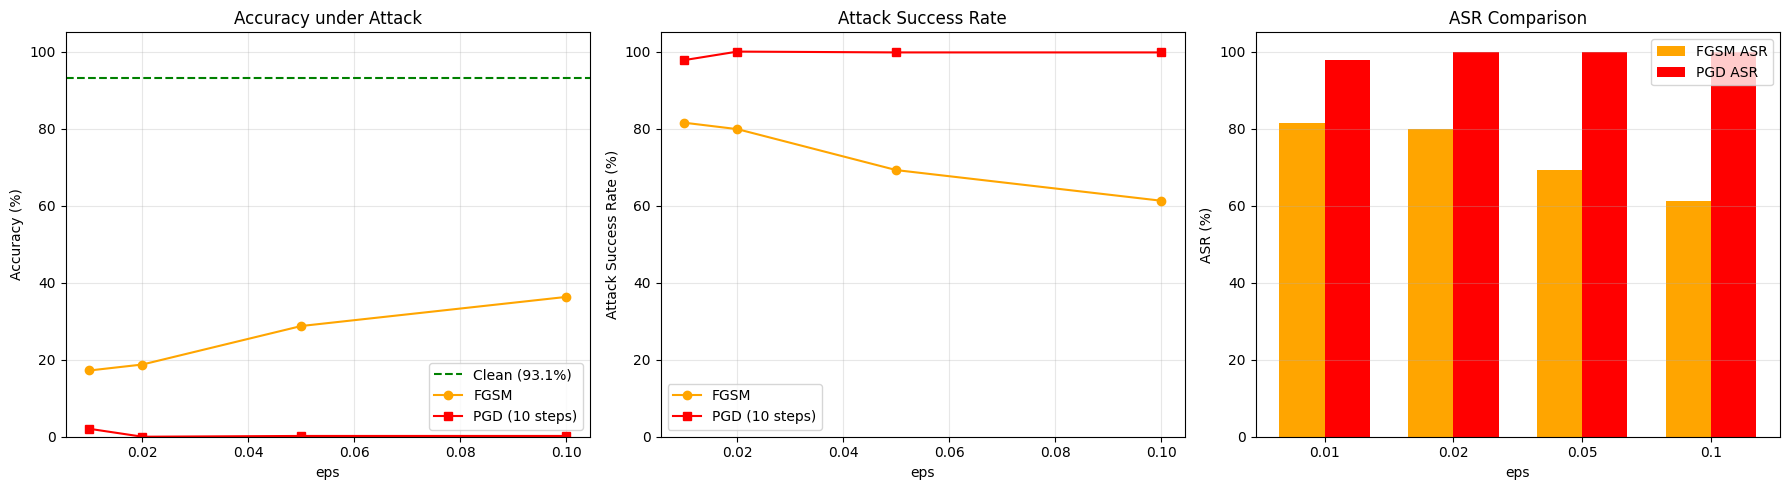


   eps |  Clean Acc |   FGSM Acc |   FGSM ASR |   PGD Acc |   PGD ASR
  0.01 |     93.10% |     17.20% |     81.53% |     2.05% |    97.80%
  0.02 |     93.10% |     18.75% |     79.86% |     0.00% |   100.00%
  0.05 |     93.10% |     28.75% |     69.23% |     0.20% |    99.79%
  0.10 |     93.10% |     36.30% |     61.28% |     0.20% |    99.79%


In [8]:
eps_list  = EPS_VALUES
fgsm_accs = [fgsm_results[e]['acc'] * 100 for e in eps_list]
pgd_accs  = [pgd_results[e]['acc']  * 100 for e in eps_list]
fgsm_asrs = [fgsm_results[e]['asr'] * 100 for e in eps_list]
pgd_asrs  = [pgd_results[e]['asr']  * 100 for e in eps_list]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.axhline(clean_acc * 100, color='green', linestyle='--', label=f'Clean ({clean_acc*100:.1f}%)')
ax.plot(eps_list, fgsm_accs, 'o-', color='orange', label='FGSM')
ax.plot(eps_list, pgd_accs,  's-', color='red',    label=f'PGD ({PGD_STEPS} steps)')
ax.set_xlabel('eps'); ax.set_ylabel('Accuracy (%)'); ax.set_title('Accuracy under Attack')
ax.legend(); ax.set_ylim(0, 105); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(eps_list, fgsm_asrs, 'o-', color='orange', label='FGSM')
ax.plot(eps_list, pgd_asrs,  's-', color='red',    label=f'PGD ({PGD_STEPS} steps)')
ax.set_xlabel('eps'); ax.set_ylabel('Attack Success Rate (%)'); ax.set_title('Attack Success Rate')
ax.legend(); ax.set_ylim(0, 105); ax.grid(True, alpha=0.3)

ax = axes[2]
x = np.arange(len(eps_list)); w = 0.35
ax.bar(x - w/2, fgsm_asrs, w, label='FGSM ASR', color='orange')
ax.bar(x + w/2, pgd_asrs,  w, label='PGD ASR',  color='red')
ax.set_xticks(x); ax.set_xticklabels([str(e) for e in eps_list])
ax.set_xlabel('eps'); ax.set_ylabel('ASR (%)'); ax.set_title('ASR Comparison')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'\n{"":=<65}')
print(f'{"eps":>6} | {"Clean Acc":>10} | {"FGSM Acc":>10} | {"FGSM ASR":>10} | {"PGD Acc":>9} | {"PGD ASR":>9}')
print(f'{"":=<65}')
for e in eps_list:
    print(f'{e:>6.2f} | {clean_acc*100:>9.2f}% | {fgsm_results[e]["acc"]*100:>9.2f}% | {fgsm_results[e]["asr"]*100:>9.2f}% | {pgd_results[e]["acc"]*100:>8.2f}% | {pgd_results[e]["asr"]*100:>8.2f}%')
print(f'{"":=<65}')

Collected 4 images from classes: [5, 24, 31, 12]


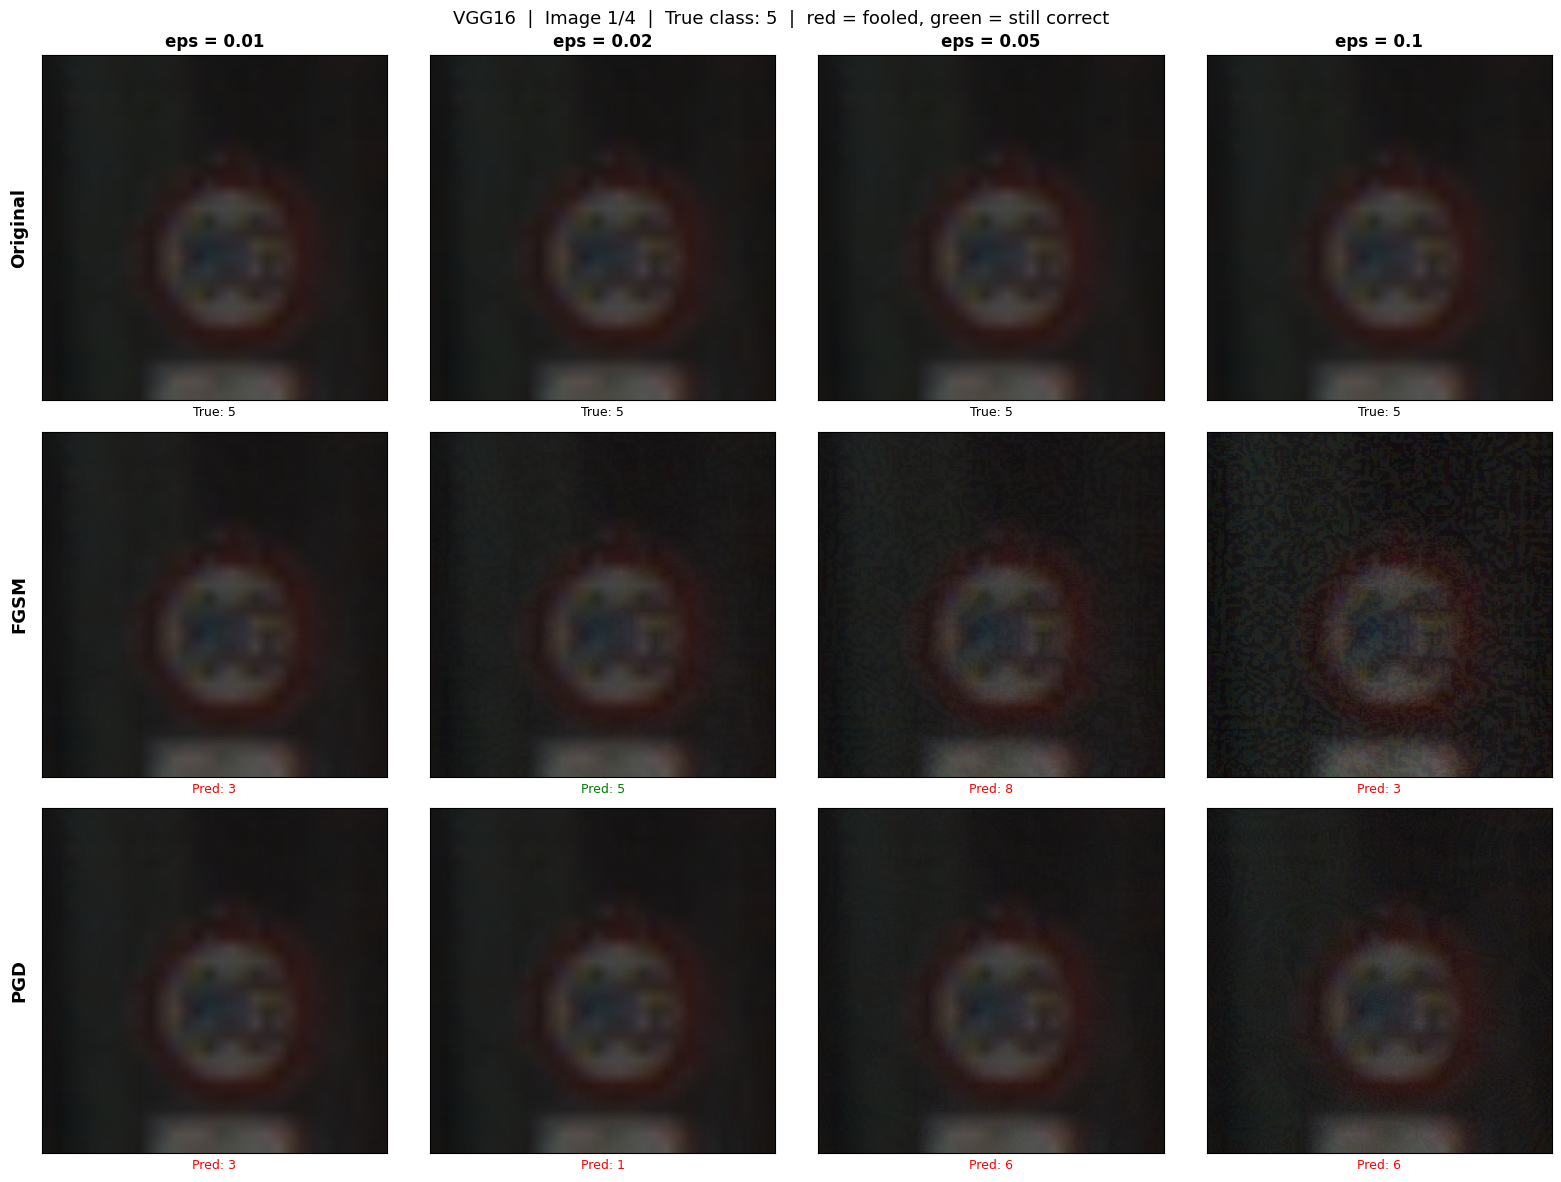

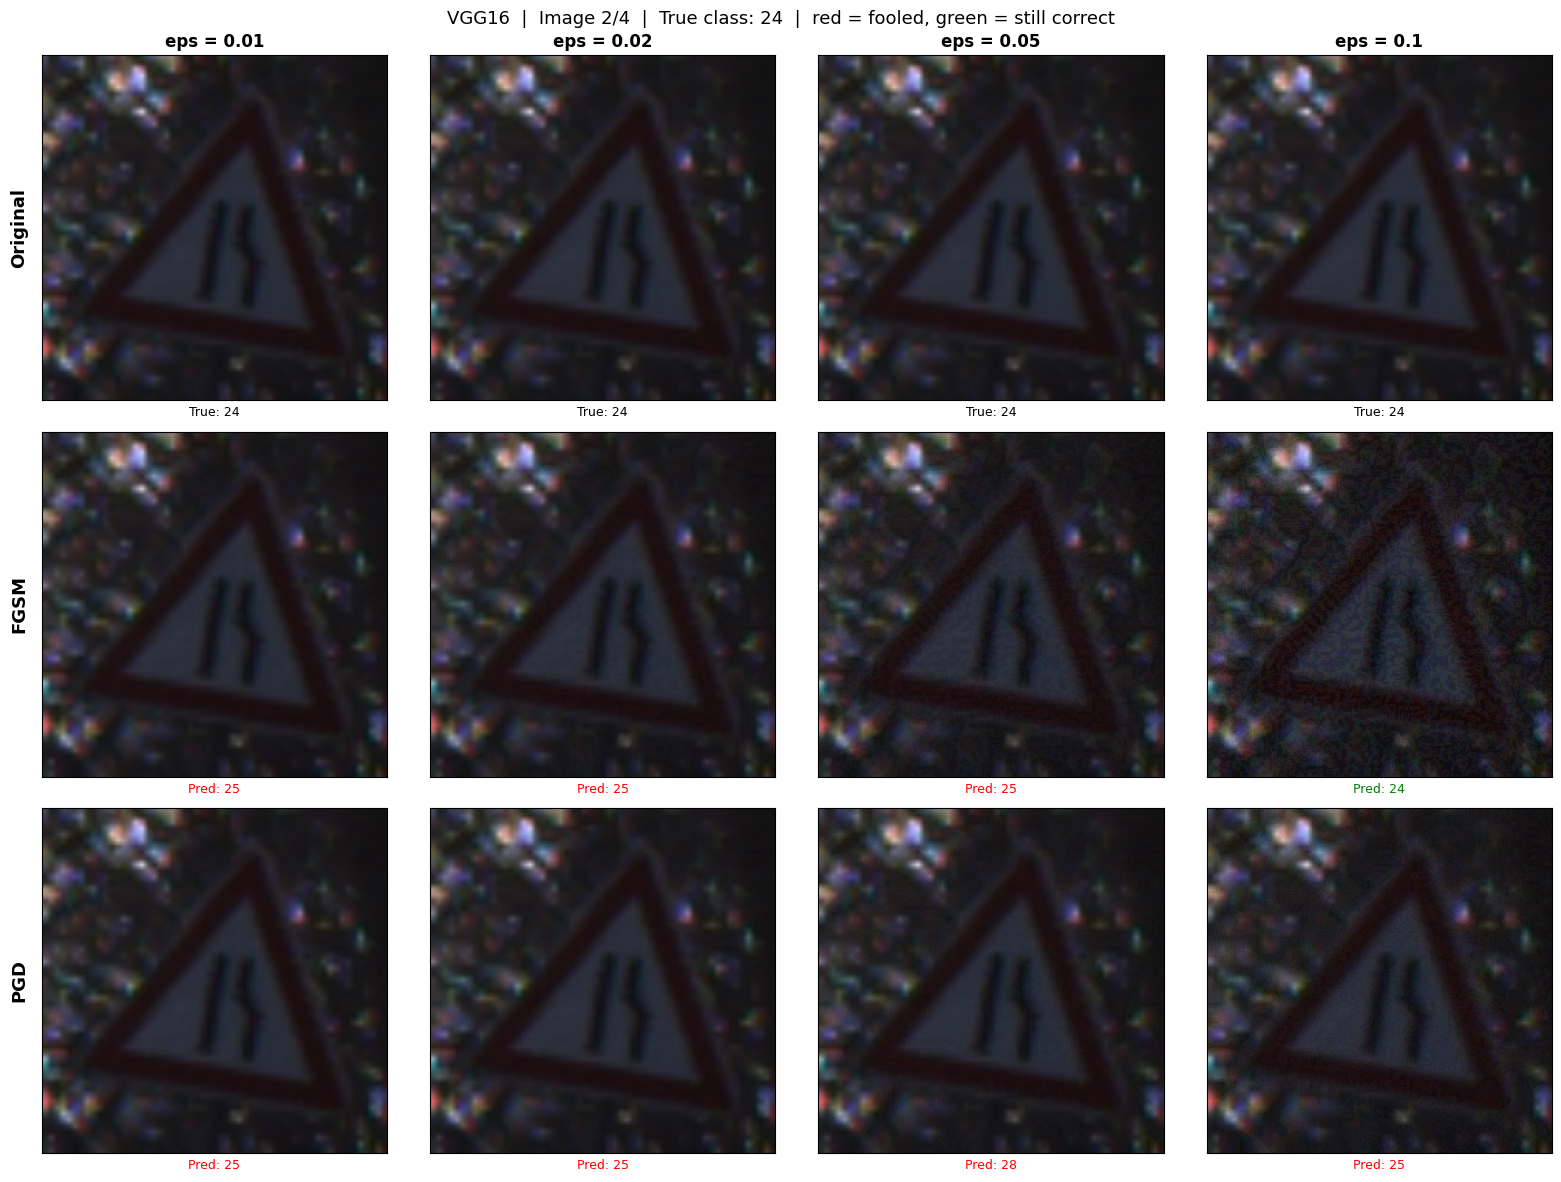

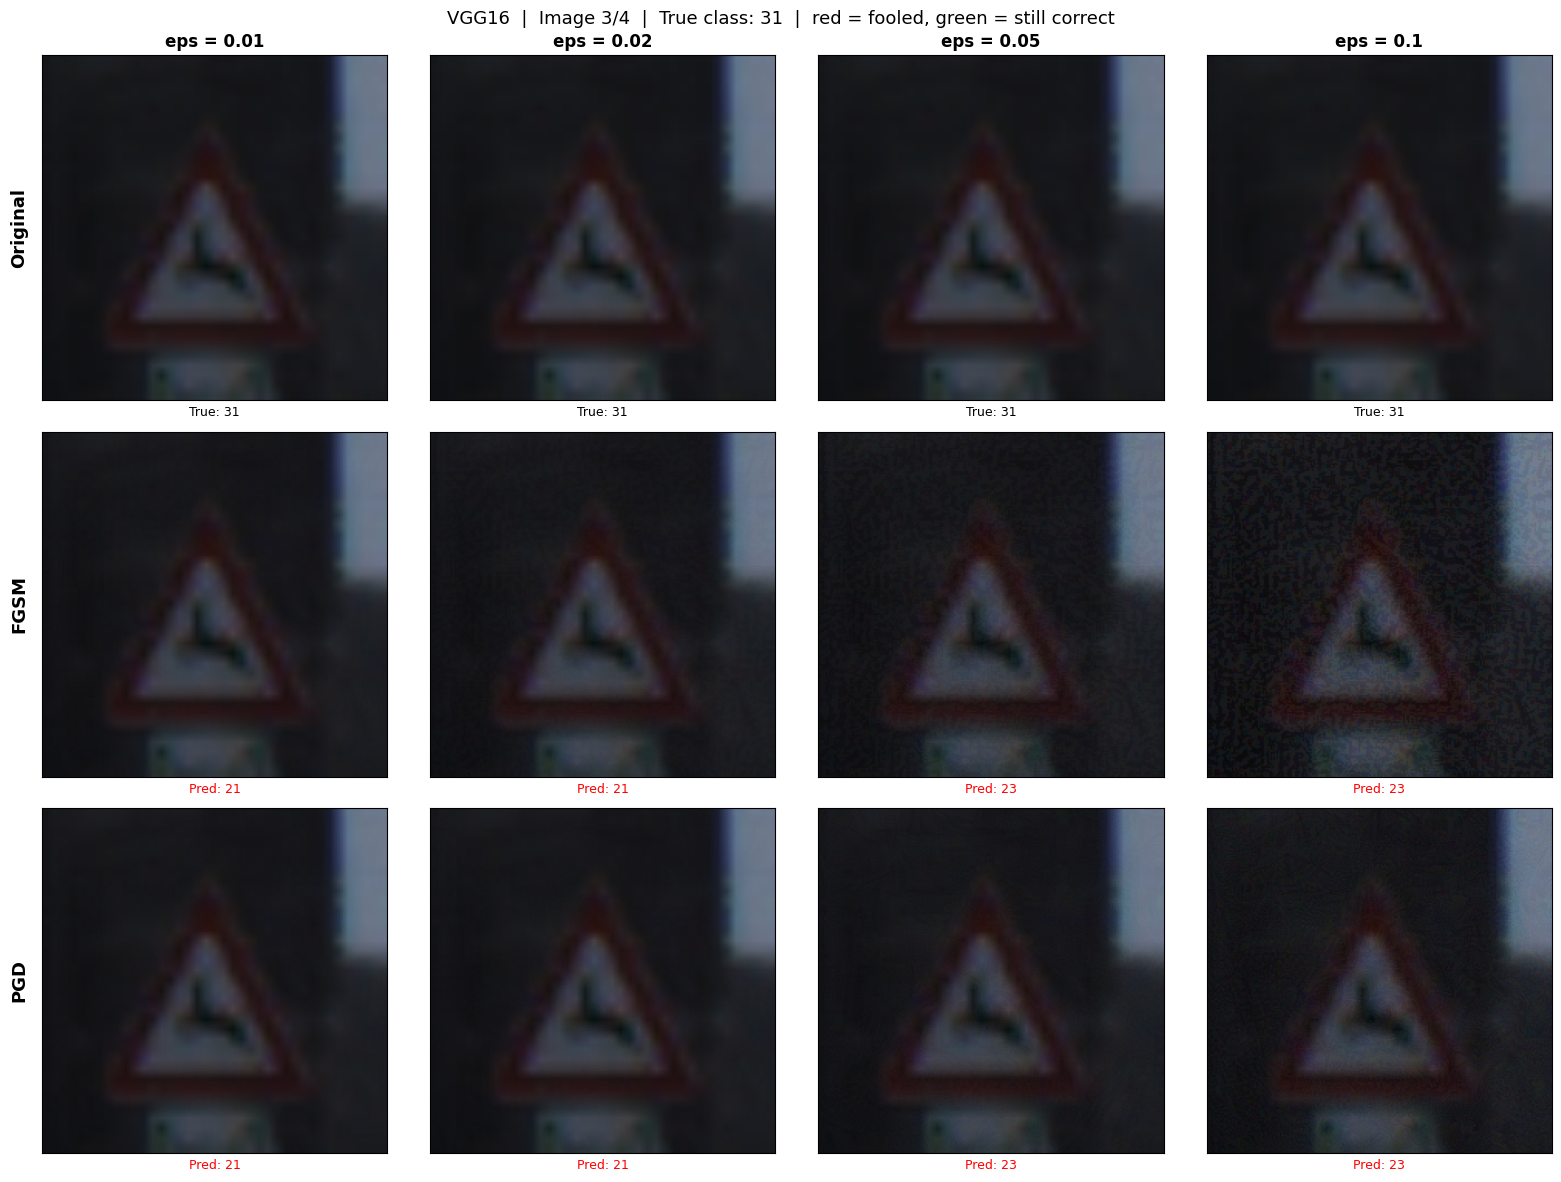

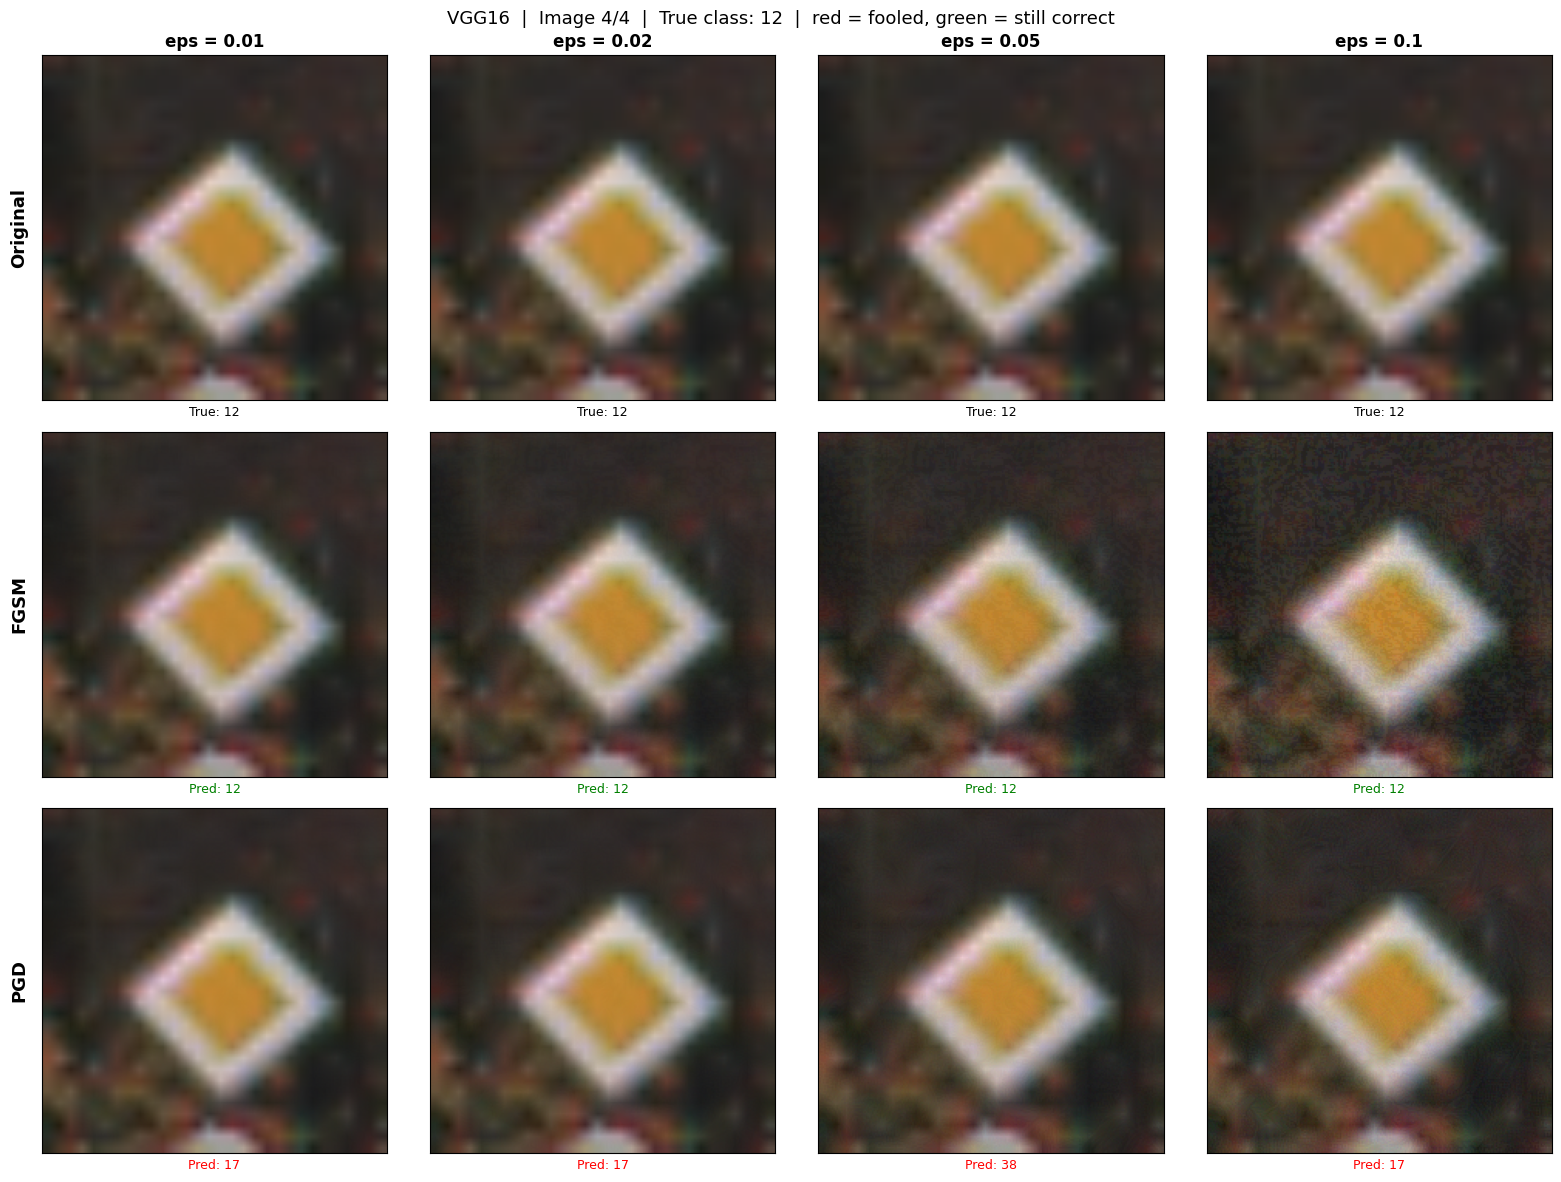

In [9]:
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1/s for s in IMAGENET_STD]
)

def to_img(t):
    return inv_normalize(t.cpu()).permute(1, 2, 0).clamp(0, 1).numpy()

N_VIS = 4   # number of images to compare

# Collect N_VIS correctly-classified images from different classes
vis_samples = []
seen_labels = set()
for imgs, labels in test_loader:
    imgs, labels = imgs.to(device), labels.to(device)
    with torch.no_grad():
        preds = model(imgs).argmax(1)
    for i in range(len(imgs)):
        lbl = labels[i].item()
        if preds[i] == labels[i] and lbl not in seen_labels:
            vis_samples.append((imgs[i], lbl))
            seen_labels.add(lbl)
            if len(vis_samples) == N_VIS:
                break
    if len(vis_samples) == N_VIS:
        break

print(f'Collected {len(vis_samples)} images from classes: {[s[1] for s in vis_samples]}')

# One 3x4 figure per image: rows=[Original, FGSM, PGD], cols=[eps values]
row_labels = ['Original', 'FGSM', 'PGD']
n_cols = len(EPS_VALUES)

for img_idx, (sample_img, sample_label) in enumerate(vis_samples):
    fig, axes = plt.subplots(3, n_cols, figsize=(4 * n_cols, 4 * 3))

    for ax, label in zip(axes[:, 0], row_labels):
        ax.set_ylabel(label, fontsize=13, fontweight='bold', rotation=90, labelpad=10)

    img_batch = sample_img.unsqueeze(0)
    label_t   = torch.tensor([sample_label], device=device)

    for col, eps in enumerate(EPS_VALUES):
        alpha    = eps / 10
        fgsm_img = fgsm_attack(model, img_batch, label_t, eps)[0]
        pgd_img  = pgd_attack(model, img_batch, label_t, eps, alpha, PGD_STEPS)[0]

        with torch.no_grad():
            fgsm_pred = model(fgsm_img.unsqueeze(0)).argmax(1).item()
            pgd_pred  = model(pgd_img.unsqueeze(0)).argmax(1).item()

        axes[0, col].imshow(to_img(sample_img))
        axes[0, col].set_title(f'eps = {eps}', fontsize=12, fontweight='bold')
        axes[0, col].set_xlabel(f'True: {sample_label}', fontsize=9)

        axes[1, col].imshow(to_img(fgsm_img))
        axes[1, col].set_xlabel(f'Pred: {fgsm_pred}', fontsize=9,
                                color='red' if fgsm_pred != sample_label else 'green')

        axes[2, col].imshow(to_img(pgd_img))
        axes[2, col].set_xlabel(f'Pred: {pgd_pred}', fontsize=9,
                                color='red' if pgd_pred != sample_label else 'green')

    for ax in axes.flat:
        ax.set_xticks([]); ax.set_yticks([])

    plt.suptitle(
        f'VGG16  |  Image {img_idx + 1}/{N_VIS}  |  True class: {sample_label}  |  '
        f'red = fooled, green = still correct',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

In [10]:
from torchvision.utils import save_image

SAVE_DIR  = 'adversarial_samples_vgg16'
SAVE_EPS  = [0.01, 0.05]
N_SAMPLES = 4

os.makedirs(SAVE_DIR, exist_ok=True)

def tensor_to_pil(t):
    img = inv_normalize(t.cpu()).clamp(0, 1)
    return transforms.ToPILImage()(img)

# Collect N_SAMPLES correctly-classified images
samples = []
for imgs, labels in test_loader:
    imgs, labels = imgs.to(device), labels.to(device)
    with torch.no_grad():
        preds = model(imgs).argmax(1)
    for i in range(len(imgs)):
        if (preds[i] == labels[i]) and len(samples) < N_SAMPLES:
            samples.append((imgs[i], labels[i].item()))
    if len(samples) == N_SAMPLES:
        break

for eps in SAVE_EPS:
    eps_dir = os.path.join(SAVE_DIR, f'eps_{eps}')
    os.makedirs(eps_dir, exist_ok=True)
    alpha = eps / 10

    for idx, (img, true_label) in enumerate(samples):
        img_batch = img.unsqueeze(0)
        label_t   = torch.tensor([true_label], device=device)

        fgsm_img = fgsm_attack(model, img_batch, label_t, eps)[0]
        pgd_img  = pgd_attack(model, img_batch, label_t, eps, alpha, PGD_STEPS)[0]

        with torch.no_grad():
            fgsm_pred = model(fgsm_img.unsqueeze(0)).argmax(1).item()
            pgd_pred  = model(pgd_img.unsqueeze(0)).argmax(1).item()

        tensor_to_pil(img).save(     os.path.join(eps_dir, f'sample{idx}_original_true{true_label}.png'))
        tensor_to_pil(fgsm_img).save(os.path.join(eps_dir, f'sample{idx}_fgsm_pred{fgsm_pred}.png'))
        tensor_to_pil(pgd_img).save( os.path.join(eps_dir, f'sample{idx}_pgd_pred{pgd_pred}.png'))

        perturbation_vis = (pgd_img - img).cpu()
        pert_show = (perturbation_vis.permute(1,2,0).numpy() * 10 + 0.5).clip(0, 1)

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        fig.suptitle(f'VGG16 | Sample {idx} | True class: {true_label} | eps={eps}', fontsize=12)
        axes[0].imshow(tensor_to_pil(img));       axes[0].set_title(f'Original\nTrue: {true_label}')
        axes[1].imshow(tensor_to_pil(fgsm_img));  axes[1].set_title(f'FGSM\nPred: {fgsm_pred}', color='red' if fgsm_pred != true_label else 'green')
        axes[2].imshow(tensor_to_pil(pgd_img));   axes[2].set_title(f'PGD\nPred: {pgd_pred}',   color='red' if pgd_pred  != true_label else 'green')
        axes[3].imshow(pert_show);                 axes[3].set_title('Perturbation x10')
        for ax in axes: ax.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(eps_dir, f'sample{idx}_comparison.png'), dpi=150, bbox_inches='tight')
        plt.close()

        print(f'eps={eps} | Sample {idx} | FGSM pred={fgsm_pred} | PGD pred={pgd_pred} -> saved')

print(f'\nAll images saved under: {os.path.abspath(SAVE_DIR)}/')

eps=0.01 | Sample 0 | FGSM pred=3 | PGD pred=3 -> saved
eps=0.01 | Sample 1 | FGSM pred=25 | PGD pred=25 -> saved
eps=0.01 | Sample 2 | FGSM pred=21 | PGD pred=21 -> saved
eps=0.01 | Sample 3 | FGSM pred=12 | PGD pred=17 -> saved
eps=0.05 | Sample 0 | FGSM pred=8 | PGD pred=6 -> saved
eps=0.05 | Sample 1 | FGSM pred=25 | PGD pred=28 -> saved
eps=0.05 | Sample 2 | FGSM pred=23 | PGD pred=23 -> saved
eps=0.05 | Sample 3 | FGSM pred=12 | PGD pred=17 -> saved

All images saved under: c:\Users\tayya\Downloads\constaing paper\transport aml stuff\adversarial_samples_vgg16/
